<a href="https://colab.research.google.com/github/tjdux/Introduction-to-Machine-Learning-with-Python/blob/main/06_5_%EC%A0%84%EC%B2%98%EB%A6%AC%EC%99%80_%EB%AA%A8%EB%8D%B8%EC%9D%98_%EB%A7%A4%EA%B0%9C%EB%B3%80%EC%88%98%EB%A5%BC_%EC%9C%84%ED%95%9C_%EA%B7%B8%EB%A6%AC%EB%93%9C_%EC%84%9C%EC%B9%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 노트북이 코랩에서 실행 중인지 체크합니다.
import os
import sys
if 'google.colab' in sys.modules and not os.path.isdir('mglearn'):
    # mglearn을 다운받고 압축을 풉니다.
    !wget -q -O mglearn.tar.gz https://bit.ly/mglearn-tar-gz
    !tar -xzf mglearn.tar.gz
    !wget -q -O data.tar.gz https://bit.ly/data-tar-gz
    !tar -xzf data.tar.gz
    # 나눔 폰트를 설치합니다.
    !sudo apt-get -qq -y install fonts-nanum
    import matplotlib.font_manager as fm
    font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
    for fpath in font_files:
        fm.fontManager.addfont(fpath)

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 117528 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [2]:
import sklearn
from preamble import *
import matplotlib

# 나눔 폰트를 사용합니다.
matplotlib.rc('font', family='NanumBarunGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

/content/mglearn/datasets.py:31: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


- 파이프라인의 장점
  - 머신러닝 워크플로에 필요한 모든 처리 단계를 하나의 scikit-learn 추정기로 캡슐화 가능
  - 지도 학습의 출력을 이용해서 전처리 매개변수 조정 가능

In [10]:
# 데이터 로드
from sklearn.model_selection import train_test_split

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

X_train, X_test, y_train, y_test = train_test_split(
    data, target, random_state=0
)

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-1452345123.py:5: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


In [4]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline

# 데이터 스케일 조정, 다항식 특성 선택, 리지 회귀
pipe = make_pipeline(StandardScaler(), PolynomialFeatures(), Ridge())

- 다항식 차수, 몇 개의 다항식이나 교차항이 필요한지는 그리드 서치의 결과에 기초해서 `degree` 매개변수를 선택해야 함

In [5]:
param_grid = {"polynomialfeatures__degree": [1, 2, 3],
             "ridge__alpha": [0.001, 0.01, 0.1, 1, 10, 100]}

In [6]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(pipe, param_grid=param_grid, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('polynomialfeatures',
                                        PolynomialFeatures()),
                                       ('ridge', Ridge())]),
             n_jobs=-1,
             param_grid={'polynomialfeatures__degree': [1, 2, 3],
                         'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100]})

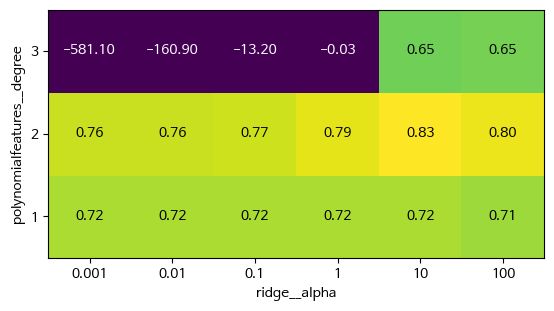

In [7]:
# 다항식 차수와 Ridge의 alpha 매개변수에 따른 교차 검증 평균 점수의 히트맵
mglearn.tools.heatmap(grid.cv_results_["mean_test_score"].reshape(3, -1),
                      xlabel="ridge__alpha", ylabel="polynomialfeatures__degree",
                      xticklabels=param_grid["ridge__alpha"],
                      yticklabels=param_grid["polynomialfeatures__degree"], vmin=0)

In [8]:
print(f"최적의 매개변수: {grid.best_params_}")

최적의 매개변수: {'polynomialfeatures__degree': 2, 'ridge__alpha': 10}


- 2차항이 효과가 좋고 3차항은 1, 2차보다 결과가 나쁨

In [11]:
print(f"테스트 세트 점수: {round(grid.score(X_test, y_test), 2)}")

테스트 세트 점수: 0.77


In [12]:
# 다항식 특성이 없는 그리드

param_grid = {"ridge__alpha": [0.001, 0.01, 0.1, 1, 10, 100]}
pipe = make_pipeline(StandardScaler(), Ridge())
grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(X_train, y_train)

print(f"다항 특성이 없을 때 점수: {round(grid.score(X_test, y_test), 2)}")

다항 특성이 없을 때 점수: 0.63
